## DMRG WITH TENPY

In [74]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pickle
import os


import tenpy
from tenpy import CouplingMPOModel, SpinHalfSite
import tenpy.linalg.np_conserved as npc
from tenpy.algorithms import dmrg
from tenpy.networks.mps import MPS
from tenpy.models.tf_ising import TFIChain

np.set_printoptions(precision=5, suppress=True, linewidth=100)
plt.rcParams['figure.dpi'] = 150
tenpy.tools.misc.setup_logging(to_stdout="INFO")

In [75]:
L = 100


filename = os.path.join(os.getcwd(), "TFIM")

## My MPO

In [ ]:
class myModel(CouplingMPOModel):
    def init_sites(self, model_params):
        return SpinHalfSite(conserve='None')
    
    def init_terms(self, model_params):
        Jx = model_params.get('Jx', 1.0)
        hz = model_params.get('hz', 0.0)
        kl = model_params.get('kl', 0.0)
        kr = model_params.get('kr', 0.0)

        # Onsite magnetic field
        for u in range(len(self.lat.unit_cell)):
            self.add_onsite(hz, u, 'Sz')

        # Nearest-neighbor XX coupling
        for u1, u2, dx in self.lat.pairs['nearest_neighbors']:
            self.add_coupling(Jx, u1, 'Sx', u2, 'Sx', dx)

        # 3-site interactions (already Hermitian)
        dx = [(0,), (1,), (2,)]
        u = 0  # single-site unit cell

        self.add_multi_coupling(
            kl,
            [('Sx', dx[0], u), ('Sy', dx[1], u), ('Sz', dx[2], u)]
        )
        self.add_multi_coupling(
            -kl,
            [('Sy', dx[0], u), ('Id', dx[1], u), ('Sx', dx[2], u)]
        )
        self.add_multi_coupling(
            -kr,
            [('Sz', dx[0], u), ('Sy', dx[1], u), ('Sx', dx[2], u)]
        )
        self.add_multi_coupling(
            kr,
            [('Sx', dx[0], u), ('Id', dx[1], u), ('Sy', dx[2], u)]
        )

        # add boundary conditions
        self.add_onsite_term(10, 0, "Sx")
        self.add_onsite_term(-10, L-1, "Sx")

def dmrg_sim(Jx, hz, kl, kr, filename=filename):
    dmrg_params = {
    'mixer': True,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-7,
    'trunc_params': {
        'chi_max': 200,
        'svd_min': 1.e-10,
    },
    'combine': True
    }

    model_params = {
    'Jx': Jx , 'hz': hz, 'kl': kl, 'kr': kr,
    'L': L,
    'bc_MPS': 'finite',
    }

    M = myModel(model_params)
    psi = MPS.from_lat_product_state(M.lat, [['up']])

    eng = dmrg.TwoSiteDMRGEngine(psi, M, dmrg_params)
    E, psi = eng.run() # the main work; modifies psi in place

    # save to file
    data = {'psi': psi, 'dmrg_params': dmrg_params, 'model_params': model_params}

    if not os.path.exists(filename):
        os.mkdir(filename)
        
    loc = os.path.join(filename, f'{hz:.3f}_{kl:.3f}.pkl')
    with open(loc, 'wb') as f:
        pickle.dump(data, f)
    
    return M

def dmrg_lines(start, stop, step, fixed, setval="k", Jx=1):
    values = np.arange(start, stop+step, step)

    for sweep in values:
        if setval == "k":
            hz = sweep
            k = fixed
        elif setval == "h":
            hz = fixed
            k = sweep
        print(Jx, hz, k)
        M = dmrg_sim(Jx, hz, k, k)
        print(M.all_coupling_terms().to_TermList() + M.all_onsite_terms().to_TermList())

dmrg_lines(0.4, 1, 0.1, 0, setval="h")

1 0 0.0
INFO    : myModel: reading 'bc_MPS'='finite'
INFO    : myModel: reading 'L'=100
INFO    : myModel: reading 'Jx'=1
INFO    : myModel: reading 'hz'=0
INFO    : myModel: reading 'kl'=np.float64(0.0)
INFO    : myModel: reading 'kr'=np.float64(0.0)
INFO    : TwoSiteDMRGEngine: subconfig 'trunc_params'=Config(<2 options>, 'trunc_params')
INFO    : TwoSiteDMRGEngine: reading 'combine'=True
INFO    : TwoSiteDMRGEngine: reading 'mixer'=True
INFO    : activate DensityMatrixMixer with initial amplitude 1e-05
INFO    : Running sweep with optimization
INFO    : trunc_params: reading 'chi_max'=200
INFO    : trunc_params: reading 'svd_min'=1e-10
INFO    : checkpoint after sweep 1
energy=-34.7499999999998650, max S=0.0000000000000228, age=100, norm_err=5.7e-14
Current memory usage 663.3MB, wall time: 2.2s
Delta E = nan, Delta S = 2.3662e-15 (per sweep)
max trunc_err = 1.3331e-28, max E_trunc = 4.2633e-14
chi: 2
INFO    : Running sweep with optimization
INFO    : checkpoint after sweep 2
energy

KeyboardInterrupt: 

## Energy

## Magnetization Profile

/home/silvanita/Desktop/thesis/master_thesis/books/TFIM


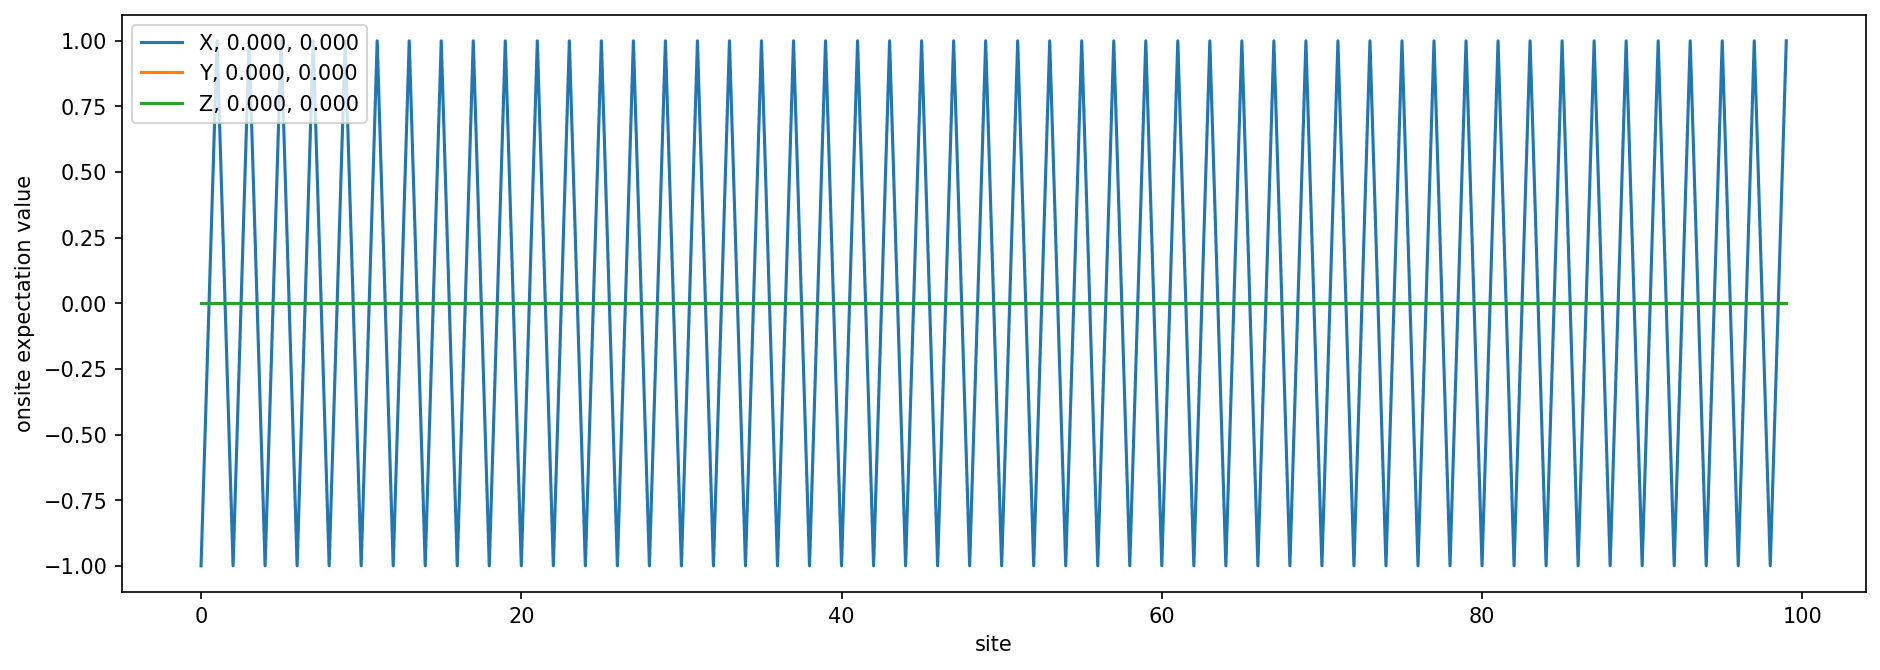

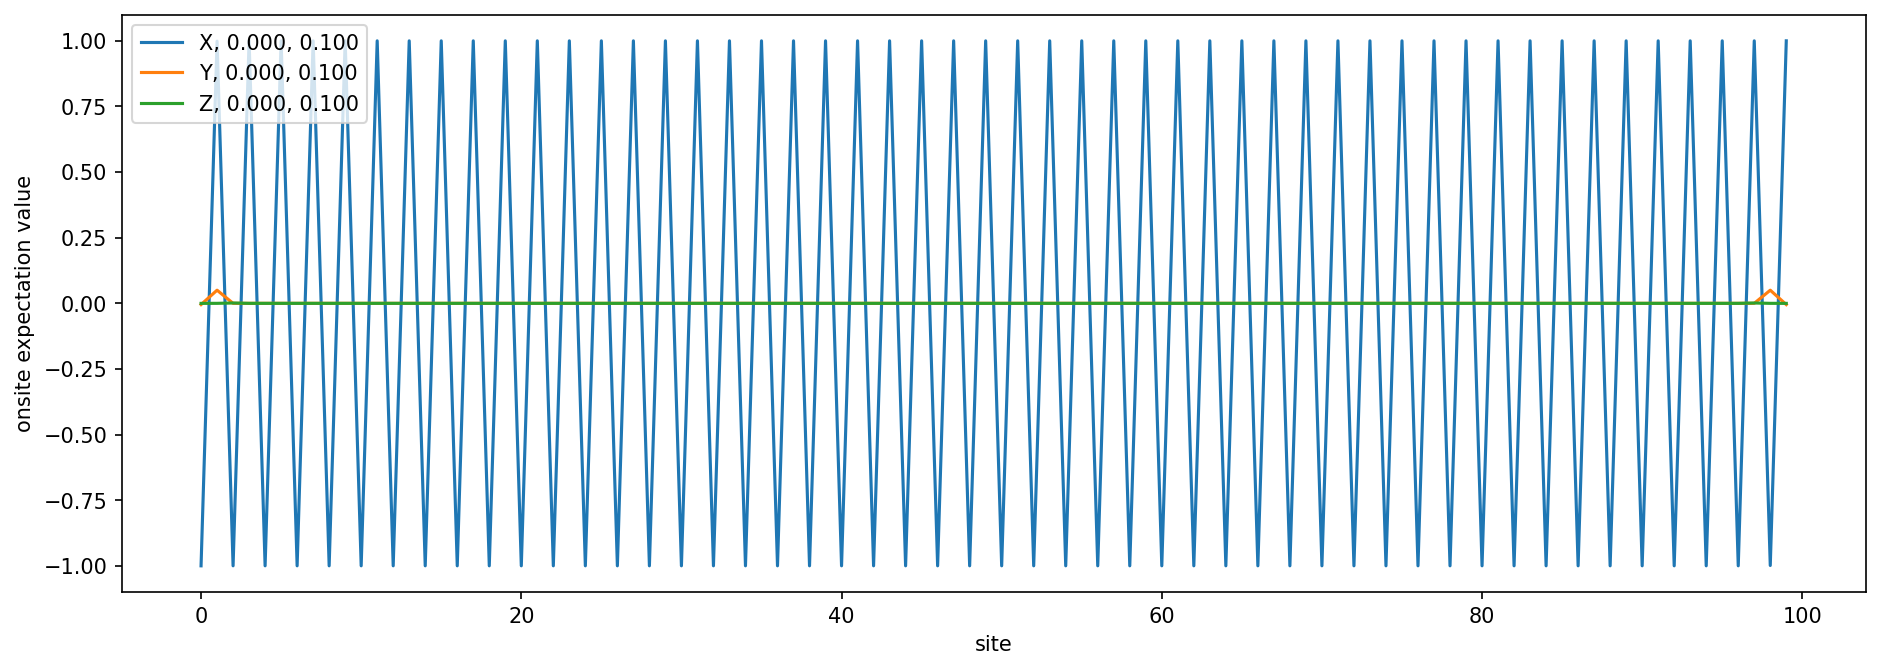

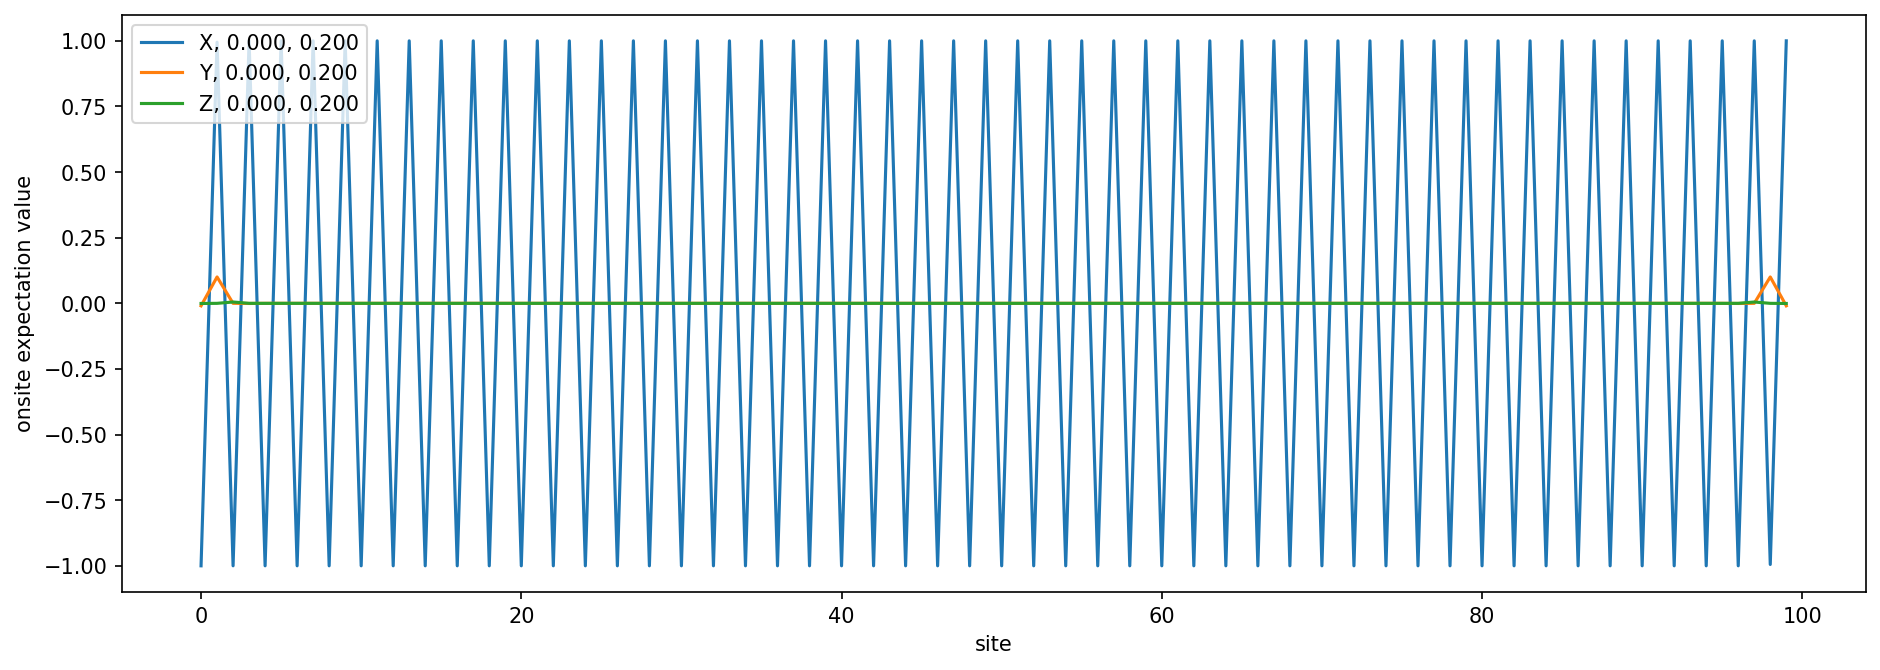

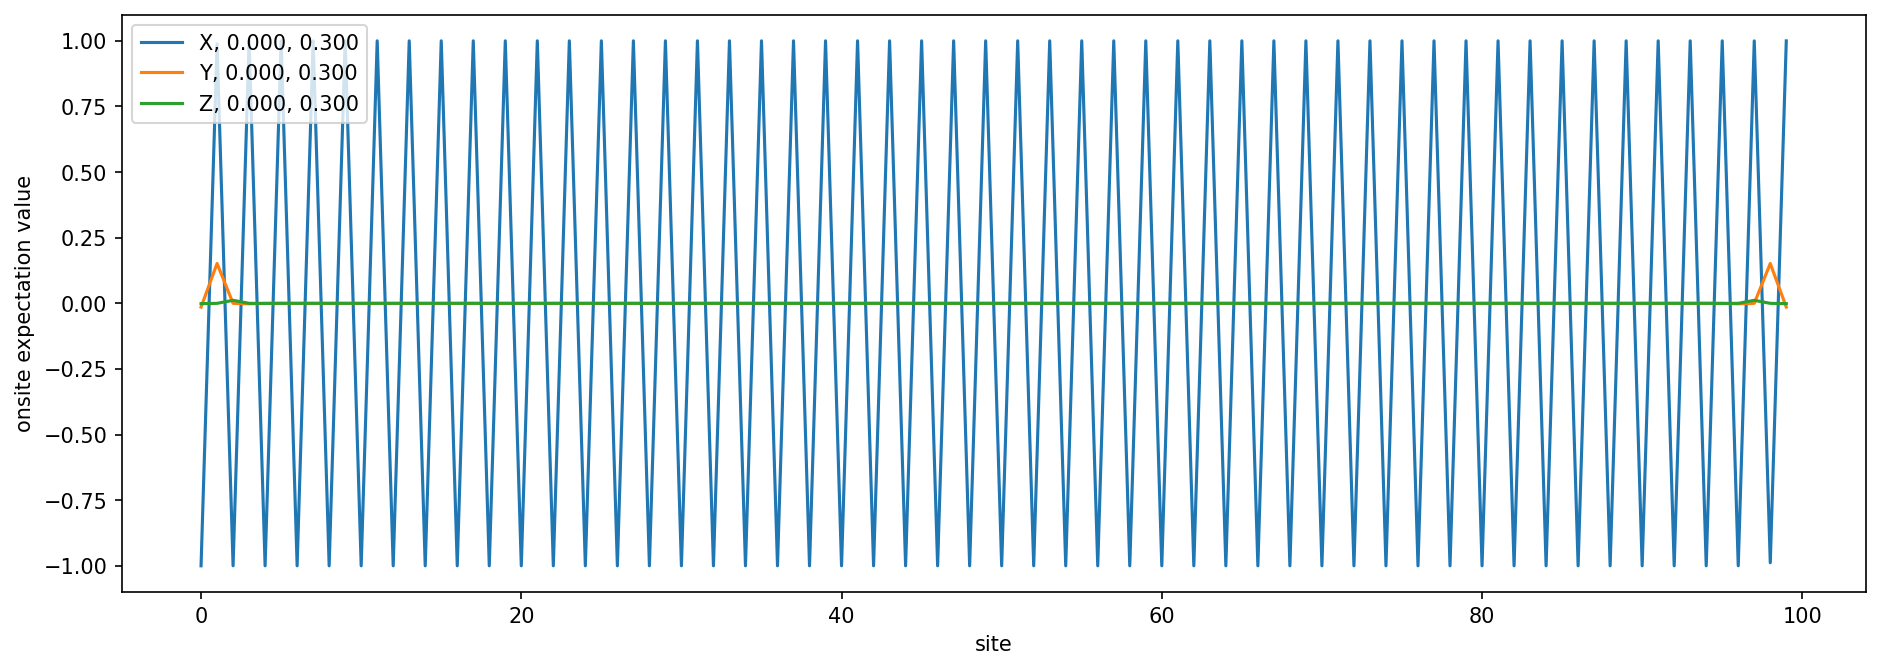

In [82]:
# onsite expectation values
filename = os.path.join(os.getcwd(), "TFIM")
print(filename)

for i in sorted(os.listdir(filename)):

    plt.figure(figsize=(15, 5))
    loc = os.path.join(filename, i)
    with open(loc, 'rb') as f:
        data = pickle.load(f)
        psi = data['psi']
    i = os.path.splitext(i)[0]
    h, k = i.split("_")
    x = np.arange(psi.L)
    X = psi.expectation_value("Sigmax")
    Z = psi.expectation_value("Sigmaz")
    Y = psi.expectation_value("Sigmay")
    
    plt.plot(x, X, label=f"X, {h}, {k}")
    plt.plot(x, Y, label=f"Y, {h}, {k}")
    plt.plot(x, Z, label=f"Z, {h}, {k}")
   
    plt.xlabel("site")
    plt.ylabel("onsite expectation value")
    plt.legend()
    plt.show()

## Correlation Functions

/home/silvanita/Desktop/thesis/master_thesis/books/TFIM
0.000_0.000.pkl
[51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99]
50
0.000_0.100.pkl
[51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99]
50
0.000_0.200.pkl
[51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99]
50
0.000_0.300.pkl
[51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99]
50


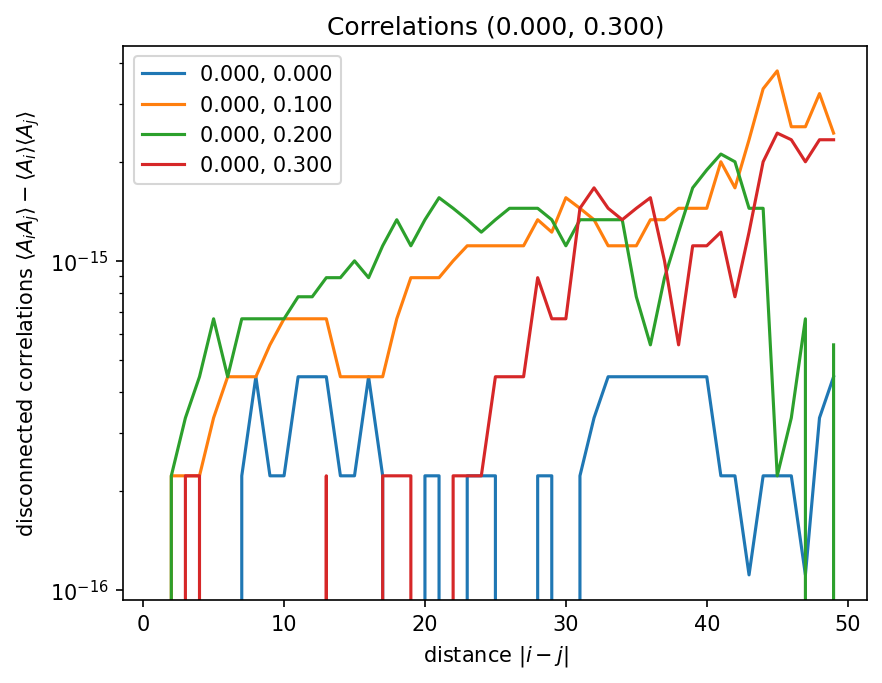

In [83]:
# correlation functions

print(filename)
plt.figure()

for i in sorted(os.listdir(filename)):
    print(i)
    loc = os.path.join(filename, i)
    with open(loc, 'rb') as f:
        data = pickle.load(f)
        psi = data['psi']
    
    i = os.path.splitext(i)[0]
    h, k = i.split("_")

    X = psi.expectation_value("Sigmax")
    Z = psi.expectation_value("Sigmaz")
    Y = psi.expectation_value("Sigmay")

    i0 = psi.L // 2  # for fixed `i`
    j = np.arange(i0 + 1, psi.L)
    print(j)
    print(i0)

    XX = psi.term_correlation_function_right([("Sigmax", 0)], [("Sigmax", 0)], i_L=i0, j_R=j)
    XX_disc = XX - X[i0] * X[j]

    # YY = psi.term_correlation_function_right([("Sigmay", 0)], [("Sigmay", 0)], i_L=i0, j_R=j)
    # YY_disc = YY - Y[i0] * Y[j]

    # ZZ = psi.term_correlation_function_right([("Sigmaz", 0)], [("Sigmaz", 0)], i_L=i0, j_R=j)
    # ZZ_disc = ZZ - Z[i0] * Z[j]

    # XY = psi.term_correlation_function_right([("Sigmax", 0)], [("Sigmay", 0)], i_L=i0, j_R=j)
    # XY_disc = XY - X[i0] * Y[j]

    # XZ = psi.term_correlation_function_right([("Sigmax", 0)], [("Sigmaz", 0)], i_L=i0, j_R=j)
    # XZ_disc = XZ - X[i0] * Z[j]

    # YZ = psi.term_correlation_function_right([("Sigmay", 0)], [("Sigmaz", 0)], i_L=i0, j_R=j)
    # YZ_disc = YZ - Y[i0] * Z[j]


    dx = j - i0
    plt.plot(dx, np.abs(XX_disc), label=f"{h}, {k}")
    # plt.plot(dx, YY_disc, label="Y Y")
    # plt.plot(dx, ZZ_disc, label="Z Z")
    # plt.plot(dx, XY_disc, label="X Y")
    # plt.plot(dx, XZ_disc, label="X Z")
    # plt.plot(dx, YZ_disc, label="Y Z")
    plt.xlabel(r"distance $|i-j|$")
    plt.ylabel(r"disconnected correlations $\langle A_i A_j\rangle - \langle A_i \rangle\langle A_j\rangle$")
    plt.title(f"Correlations ({h}, {k})")
    plt.legend()
    plt.semilogy()
plt.show()

## Entanglement Entropy

0.000_0.000.pkl
extraced central charge 0.00000 with residuum 0.00e+00
(Expect central charge = 0.5 for the transverse field Ising model.)


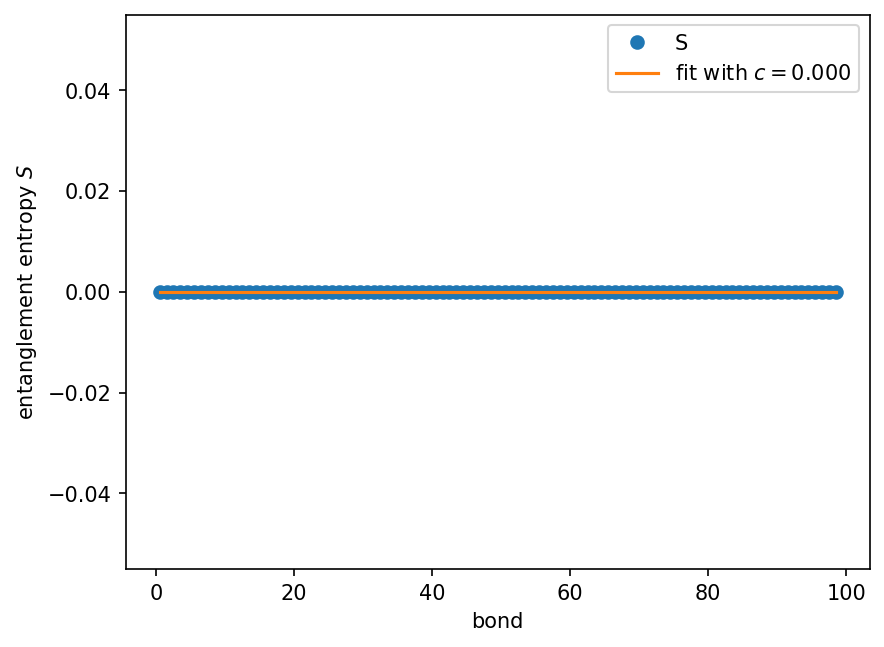

0.000_0.100.pkl
extraced central charge 0.00000 with residuum 0.00e+00
(Expect central charge = 0.5 for the transverse field Ising model.)


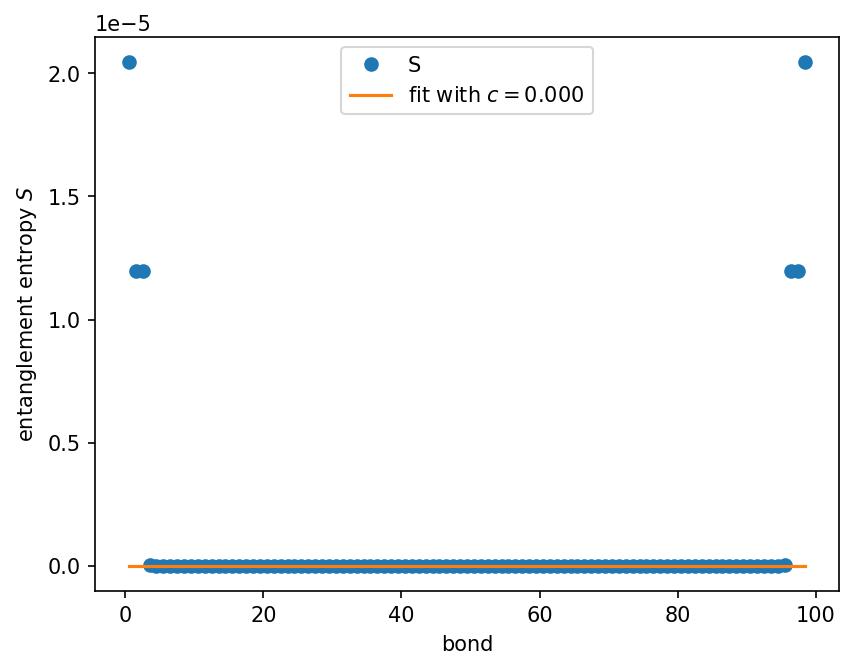

0.000_0.200.pkl
extraced central charge 0.00000 with residuum 0.00e+00
(Expect central charge = 0.5 for the transverse field Ising model.)


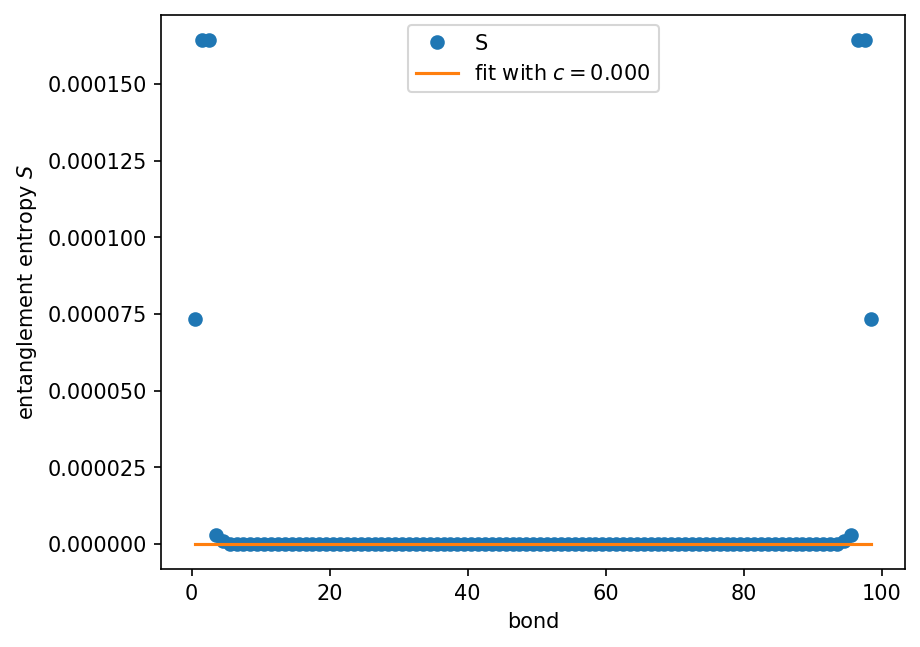

0.000_0.300.pkl
extraced central charge -0.00000 with residuum 9.55e-35
(Expect central charge = 0.5 for the transverse field Ising model.)


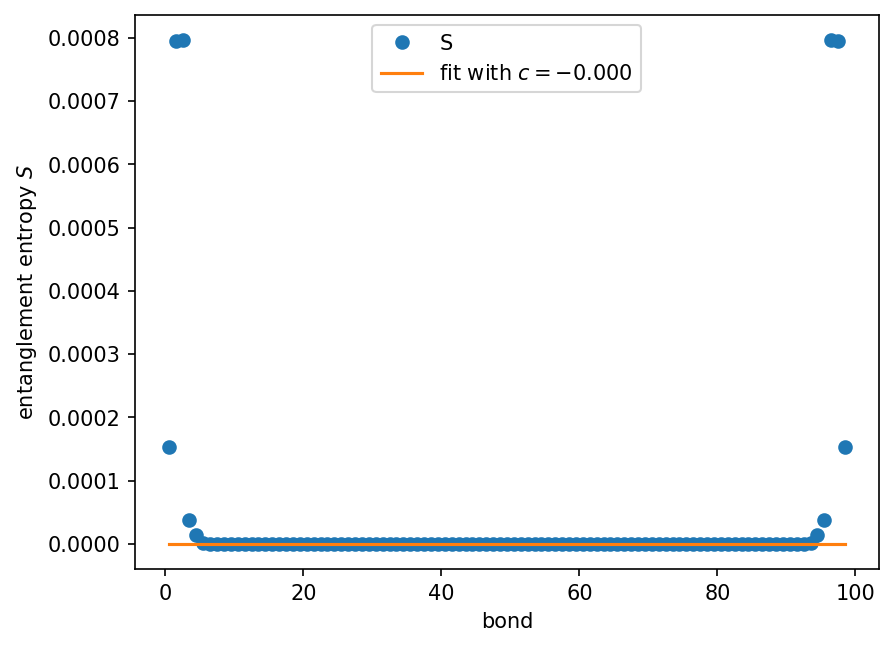

In [84]:
filename = os.path.join(os.getcwd(), "TFIM")
for i in sorted(os.listdir(filename)):
    print(i)
    loc = os.path.join(filename, i)
    with open(loc, 'rb') as f:
        data = pickle.load(f)
        psi = data['psi']
    S = psi.entanglement_entropy()

    bonds = np.arange(0.5, psi.L-1)
    plt.plot(bonds, S, 'o', label="S")

    # preform fit to extract the central charge
    central_charge, const, res = tenpy.tools.fit.central_charge_from_S_profile(psi)
    fit = tenpy.tools.fit.entropy_profile_from_CFT(bonds + 0.5, psi.L, central_charge, const)
    print(f"extraced central charge {central_charge:.5f} with residuum {res:.2e}")
    print("(Expect central charge = 0.5 for the transverse field Ising model.)")
    plt.plot(bonds, fit, label=f"fit with $c={central_charge:.3f}$")
    plt.xlabel("bond")
    plt.ylabel("entanglement entropy $S$")
    plt.legend()
    plt.show()